### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [4]:
arxiv.invoke("NA61/SHINE results on search for critical pointd")

HTTPError: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=NA61%2FSHINE+results+on+search+for+critical+pointd&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100)

In [5]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [7]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation me'

In [8]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [9]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

/tmp/ipykernel_278083/3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [10]:
tavily.invoke("Provide me the recent AI news for march 3rd 2026")

[{'title': 'Google AI announcements from March',
  'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-march-2026/',
  'content': 'Learn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\n# The latest AI news we announced in March 2026\n\nApr 01, 2026\n\nHere’s a recap of our biggest AI updates from March 2026, including an expansion of Search Live, more ways to access Personal Intelligence and new tools that make it easier to switch to Gemini.\n\n## General summary\n\nIn March, Google focused on making AI more helpful in your daily life with updates to Gemini. These updates help Gemini understand your context, turning devices into proactive helpers for work, creativity, and intuitive living. New features include expanded Search Live, enhanced AI tools in Docs, Sheets, Slides, and Drive, Google Maps upgrades, Personal Intelligence expansion, and tools to switch to Gemini. [...] ## Bullet points\n\n "The latest AI news we announ

In [11]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [12]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")

llm_with_tools=llm.bind_tools(tools)

In [13]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. I need to figure out which tool to use here. Let me check the available functions.\n\nFirst, there\'s the arxiv function, which is for scientific papers in fields like physics and computer science. But the user is asking for news, not research papers. So maybe arxiv isn\'t the best fit here.\n\nNext, the wikipedia function. Wikipedia has general information, but it might not have the most up-to-date news. Wikipedia is more for encyclopedic content rather than current events.\n\nThen there\'s the tavily_search_results_json function, which is described as a search engine optimized for current events. That sounds perfect for finding recent AI news. The user probably wants the latest updates, and this tool is designed for that purpose.\n\nSo I should use tavily_search_results_json with a query like "recent AI news" or "latest AI developments". Let me make sure the parameters are corr

In [14]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 't38ne3kpq',
  'type': 'tool_call'}]

In [15]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

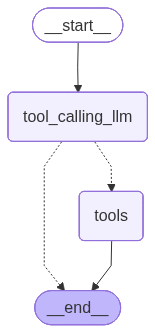

In [16]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (za7jttj11)
 Call ID: za7jttj11
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [18]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 strongest pokemons")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 strongest pokemons
================================== Ai Message ==================================
Tool Calls:
  wikipedia (deamn3c0x)
 Call ID: deamn3c0x
  Args:
    query: List of Pokémon by base statistics
================================= Tool Message =================================
Name: wikipedia

Page: List of Pokémon
Summary: The Pokémon franchise features 1028 fictional species of collectible creatures, each with unique designs, skills, and powers. Conceived by Satoshi Tajiri in early 1989, Pokémon (or Pocket Monsters) are fictional creatures that inhabit the fictional Pokémon World. The designs for the multitude of species can draw inspiration from anything, such as animals, plants, and legendary creatures. Many Pokémon are capable of evolving into more powerful species, while others 


In [22]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (132zagx6m)
 Call ID: 132zagx6m
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation me
